**Group H : Prabhleen Luthra,
Seungwoo Johnson,
Aayushi Garg,
Karen Lau,
Sarah Kamoun**



**This section was done before we realized that the hypoxic samples were in fact erronoeus data. We have decided to include this notebook to showcase our effort, time and dedication in doing this project well.**

**Note: in this earlier version, data cleaning was incomplete, which led to having several rows with 0 oxygen concentration (hypoxic samples)**

* In our final submission notebook, we found that after updating our data cleaning process (such as through using IQR) these samples disappeared.

* In this version of the code, 13324 samples have 0 oxygen, 7 of which were the negative oxygen concentration samples, mistakenly "corrected" by setting them to 0 when they should have been simply removed.

In [ ]:
print(df2.columns)

Index(['time', 'latitude', 'longitude', 'depth', 'sea_water_temperature',
       'sea_water_practical_salinity', 'sea_water_density',
       'micromoles_of_oxygen_per_unit_mass_in_sea_water'],
      dtype='object')


In [ ]:
df3=df2.copy()
drop_these=['lat_binF','lon_binF','lat_idx', 'lon_idx']
df3.drop(drop_these)

In [ ]:
print(df3.columns)

Index(['time', 'latitude', 'longitude', 'depth', 'sea_water_temperature',
       'sea_water_practical_salinity', 'sea_water_density',
       'micromoles_of_oxygen_per_unit_mass_in_sea_water', 'lat_idx', 'lon_idx',
       'quadrant', 'lat_binF', 'lon_binF', 'Year_n', 'Month_n', 'Week_n',
       'Day_n', 'Season', 'DayNight', 'hypoxia', 'Hour', 'temp_bins',
       'salinity_bins', 'depth_bins', 'density_bins', 'Depth Category',
       'temp_salinity', 'temp_density', 'temp_depth', 'salinity_density',
       'salinity_depth', 'density_depth', 'temp_salinity_bins',
       'temp_density_bins', 'temp_depth_bins', 'salinity_density_bins',
       'salinity_depth_bins', 'density_depth_bins'],
      dtype='object')


In [ ]:
print(df3['hypoxia'].value_counts())
print("percentage of data with hypoxia", df3['hypoxia'].value_counts(normalize=True)[1]*100)

hypoxia
0    4502151
1      13324
Name: count, dtype: int64
percentage of data with hypoxia 0.2950741616330508


In [ ]:
# Import necessary libraries for classification
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Logistic Regression with SMOTE for class imbalance

* We normalize numerical variables and do one-hot encoding for categorical varibales as a preprocessing step (dummy variables)

* We split the data into 80% train, 20% test

## Experiment 1 (SMOTE on full dataset)

In [ ]:
df3=df2.copy()

# Define features and target
features = ['sea_water_temperature', 'sea_water_practical_salinity',
            'sea_water_density', 'depth', 'Hour', 'Month_n', 'Season', 'DayNight']
target = 'hypoxia'

# normalization of numerical vars
scaler = StandardScaler()
num_features = ['sea_water_temperature', 'sea_water_practical_salinity',
                'sea_water_density', 'depth']
df3[num_features] = scaler.fit_transform(df3[num_features])

# One-hot encoding categorical variables
categorical_features = ['Season', 'DayNight','Hour', 'Month_n']
df3 = pd.get_dummies(df3, columns=categorical_features, drop_first=True)

features = [col for col in df3.columns if col not in ['hypoxia', 'time','micromoles_of_oxygen_per_unit_mass_in_sea_water','temp_bins', 'salinity_bins', 'Depth Category', 'temp_salinity',
       'temp_density', 'temp_depth', 'salinity_density', 'salinity_depth',
       'density_depth', 'temp_salinity_bins', 'temp_density_bins',
       'temp_depth_bins', 'salinity_density_bins', 'salinity_depth_bins',
       'density_depth_bins','lat_binF','lon_binF', 'Year_n','Day_n', 'Hour', 'lat_idx', 'lon_idx', 'quadrant']]
X = df3[features]
y = df3[target]

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Train Logistic Regression with class weights
from sklearn.linear_model import LogisticRegression

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

log_reg = LogisticRegression(class_weight='balanced', max_iter=500)
log_reg.fit(X_train, y_train)

# Predictions
y_pred_log = log_reg.predict(X_test)

# Evaluation
print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))


* Accuracy: 95% → Looks great
* Precision (0): 99% → Almost all normal cases are correctly classified.
* Recall (0): 91% → 9% of normal cases are misclassified as hypoxia.
* Precision (1): 91% → Some predicted hypoxia cases are actually normal.
*Recall (1): 99% → Almost all true hypoxia cases are caught
* False positives: 83,295 cases
* False negatives: 8,773 cases

## Experiment 2 (SMOTE on train set only)

In [ ]:
# Import necessary libraries for classification
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df3=df2.copy()

# Define features and target
features = ['sea_water_temperature', 'sea_water_practical_salinity',
            'sea_water_density', 'depth', 'Hour', 'Month_n', 'Season', 'DayNight']
target = 'hypoxia'

# normalization of numerical vars
scaler = StandardScaler()
num_features = ['sea_water_temperature', 'sea_water_practical_salinity',
                'sea_water_density', 'depth']
df3[num_features] = scaler.fit_transform(df3[num_features])

# One-hot encoding categorical variables
categorical_features = ['Season', 'DayNight','Hour', 'Month_n']
df3 = pd.get_dummies(df3, columns=categorical_features, drop_first=True)

features = [col for col in df3.columns if col not in ['hypoxia', 'time','micromoles_of_oxygen_per_unit_mass_in_sea_water','temp_bins',
        'salinity_bins', 'Depth Category', 'temp_salinity',
       'temp_density', 'temp_depth', 'salinity_density', 'salinity_depth',
       'density_depth', 'temp_salinity_bins', 'temp_density_bins',
       'temp_depth_bins', 'salinity_density_bins', 'salinity_depth_bins',
       'density_depth_bins','lat_binF','lon_binF', 'Year_n','Day_n', 'Hour', 'lat_idx', 'lon_idx', 'quadrant']]
X = df3[features]
y = df3[target]

# Split the data first
X_train, X_test, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)

# Handle class imbalance using SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Resetting indexes after resampling
X_train_resampled = X_train_resampled.reset_index(drop=True)
y_train_resampled = y_train_resampled.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

log_reg = LogisticRegression(class_weight='balanced', max_iter=500)
log_reg.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_log = log_reg.predict(X_test)

# Evaluation
print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))


* We got 0 False Positive and 1 False Negative, which is really great!

In [ ]:
import matplotlib.pyplot as plt

# For Logistic Regression coefficients
importances = log_reg.coef_[0]

# Visualize feature importances
plt.figure(figsize=(12, 6))
plt.barh(features, importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance for Predicting Hypoxia')
plt.show()


In [ ]:
cv_scores = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='f1')
print(f"Cross-validation F1 scores: {cv_scores}")
print(f"Mean F1 score: {cv_scores.mean()}")

# Random Forest with 100 trees (default) and balanced class weights

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))


* Results: 0 false positive, 2 false negative (very good results!)

In [ ]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores = cross_val_score(rf_model, X_resampled, y_resampled, cv=5, scoring='f1')

# Print cross-validation scores and mean score
print(f"Cross-validation F1 scores: {cv_scores}")
print(f"Mean cross-validation F1 score: {cv_scores.mean()}")


In [ ]:
# For Random Forest
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
importances = rf_model.feature_importances_

# Visualize feature importances
plt.figure(figsize=(12, 6))
plt.barh(features, importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance for Predicting Hypoxia')
plt.show()


# Logistic Regression Model

* In this section, we test the Logistic Regression Model (Classifier)

## experiment 1

In [ ]:
df3=df2.copy()

# Define features and target
features = ['sea_water_temperature', 'sea_water_practical_salinity',
            'sea_water_density', 'depth', 'Season']
target = 'hypoxia'

# normalization of numerical vars
scaler = StandardScaler()
num_features = ['sea_water_temperature', 'sea_water_practical_salinity',
                'sea_water_density', 'depth']
df3[num_features] = scaler.fit_transform(df3[num_features])

# One-hot encoding categorical variables
categorical_features = ['Season']
df3 = pd.get_dummies(df3, columns=categorical_features, drop_first=True)

features = [col for col in df3.columns if col not in ['hypoxia', 'time','micromoles_of_oxygen_per_unit_mass_in_sea_water',
                                                      'Year_n','Day_n', 'Hour', 'quadrant', 'temp_salinity', 'temp_density',
                                                      'temp_depth', 'salinity_density', 'salinity_depth', 'density_depth',
                                                      'Month_n', 'Week_n','Hour', 'DayNight']]
X = df3[features]
X.columns

Index(['latitude', 'longitude', 'depth', 'sea_water_temperature',
       'sea_water_practical_salinity', 'sea_water_density', 'Season_Summer',
       'Season_Winter'],
      dtype='object')

In [ ]:
y = df3[target]

# Split the data first
X_train, X_test, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)

# Handle class imbalance using SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Resetting indexes after resampling
X_train_resampled = X_train_resampled.reset_index(drop=True)
y_train_resampled = y_train_resampled.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

##################################################################################################

log_reg = LogisticRegression(class_weight='balanced', max_iter=500)
log_reg.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_log = log_reg.predict(X_test)

# Evaluation
print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92    900484
           1       0.02      0.97      0.04      2674

    accuracy                           0.85    903158
   macro avg       0.51      0.91      0.48    903158
weighted avg       1.00      0.85      0.92    903158

[[766161 134323]
 [    73   2601]]


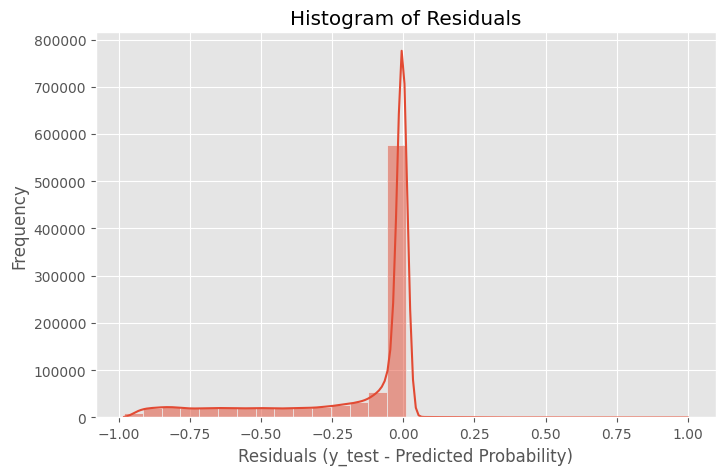

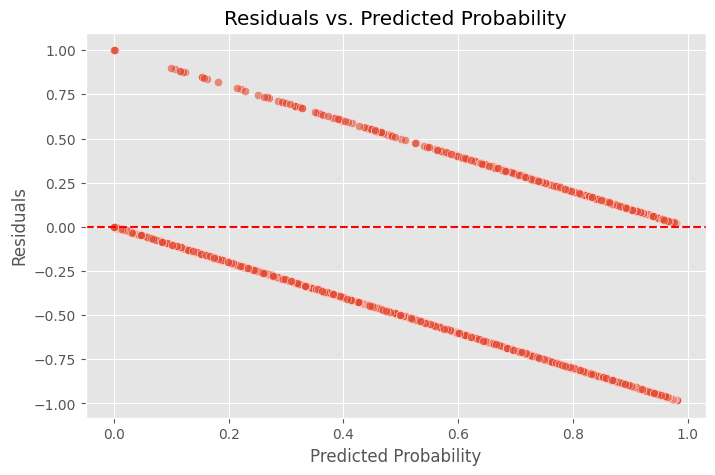

In [ ]:
# Get predicted probabilities for class 1
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]
residuals = y_test - y_pred_proba

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residuals (y_test - Predicted Probability)")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_proba, y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Probability")
plt.show()


**HISTOGRAM**
* Model is good at predicting 0s when truly 0
* Left Tail - model predicts 1 when should be 0 (false positives)
* Right tail - model rarely predicts 0 when should be 1 (false negatives)

**SCATTERPLOT**

This is normal behaviour for logistic regression residuals; there is no curve in each band; suggests it is not poorly fitting

AUC Score: 0.9628


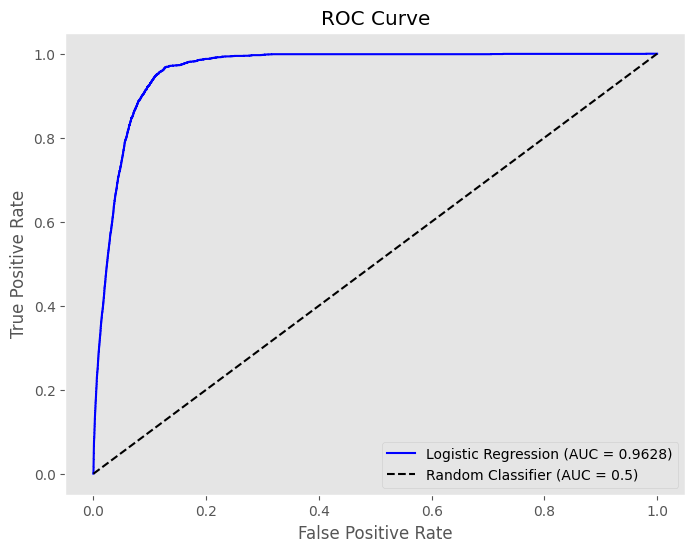

In [ ]:
# Get predicted probabilities for the positive class (class 1)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Compute AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC Score: {auc_score:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')  # Dashed diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

Pretty good AUC score!

In [ ]:
importance = pd.Series(log_reg.coef_[0], index=X_train.columns).sort_values(ascending=False)
print(importance)

Season_Summer                   672.086672
sea_water_practical_salinity      8.223810
longitude                         7.561434
depth                            -1.752346
latitude                         -5.559585
sea_water_temperature            -6.705382
sea_water_density               -11.675248
Season_Winter                   -23.465305
dtype: float64


## experiment 2

In [ ]:
df3=df2.copy()

# Define features and target
features = ['sea_water_temperature',
            'sea_water_practical_salinity', 'depth',]
target = 'hypoxia'

# normalization of numerical vars
scaler = StandardScaler()
num_features = ['sea_water_temperature', 'depth', 'sea_water_practical_salinity', 'sea_water_density']
df3[num_features] = scaler.fit_transform(df3[num_features])


# One-hot encoding categorical variables
categorical_features = ['Week_n']
df3 = pd.get_dummies(df3, columns=categorical_features, drop_first=True)

features = [col for col in df3.columns if col not in ['hypoxia', 'time','micromoles_of_oxygen_per_unit_mass_in_sea_water',
                                                      'Year_n','Day_n', 'Hour', 'quadrant', 'temp_salinity', 'temp_density',
                                                      'temp_depth', 'salinity_density', 'salinity_depth', 'density_depth',
                                                     'Season', 'DayNight','Hour', 'Month_n', 'Week_n', 'latitude', 'longitude']]
X = df3[features]
X.columns

Index(['depth', 'sea_water_temperature', 'sea_water_practical_salinity',
       'sea_water_density', 'Week_n_23', 'Week_n_24', 'Week_n_25', 'Week_n_26',
       'Week_n_27', 'Week_n_28', 'Week_n_29', 'Week_n_30', 'Week_n_31',
       'Week_n_32', 'Week_n_33', 'Week_n_34', 'Week_n_35', 'Week_n_36',
       'Week_n_37', 'Week_n_46', 'Week_n_47', 'Week_n_48'],
      dtype='object')

In [ ]:
y = df3[target]

# Split the data first
X_train, X_test, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)

# Handle class imbalance using SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Resetting indexes after resampling
X_train_resampled = X_train_resampled.reset_index(drop=True)
y_train_resampled = y_train_resampled.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

##################################################################################################

log_reg = LogisticRegression(class_weight='balanced', max_iter=500)
log_reg.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_log = log_reg.predict(X_test)

# Evaluation
print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    900484
           1       0.04      0.99      0.08      2674

    accuracy                           0.93    903158
   macro avg       0.52      0.96      0.52    903158
weighted avg       1.00      0.93      0.96    903158

[[835639  64845]
 [    33   2641]]


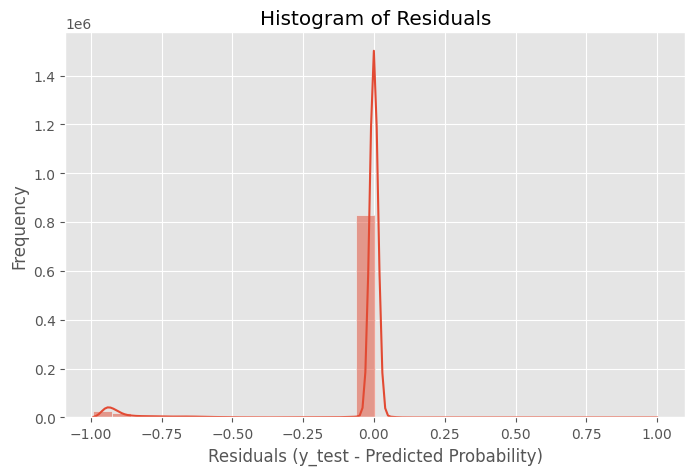

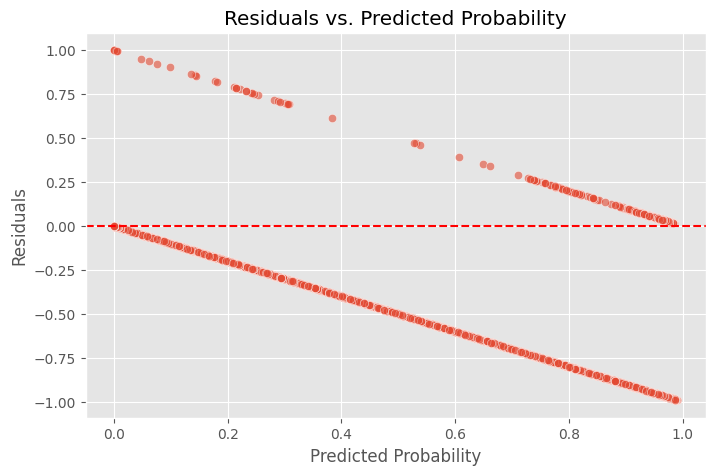

In [ ]:
# Get predicted probabilities for class 1
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]
residuals = y_test - y_pred_proba


plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residuals (y_test - Predicted Probability)")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_proba, y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Probability")
plt.show()


**Histogram**
* Centres and peaks at 0, implies accurate predictions
* Some false positives

**Scatterplot**
* No curvature in the separate lines

AUC Score: 0.9858


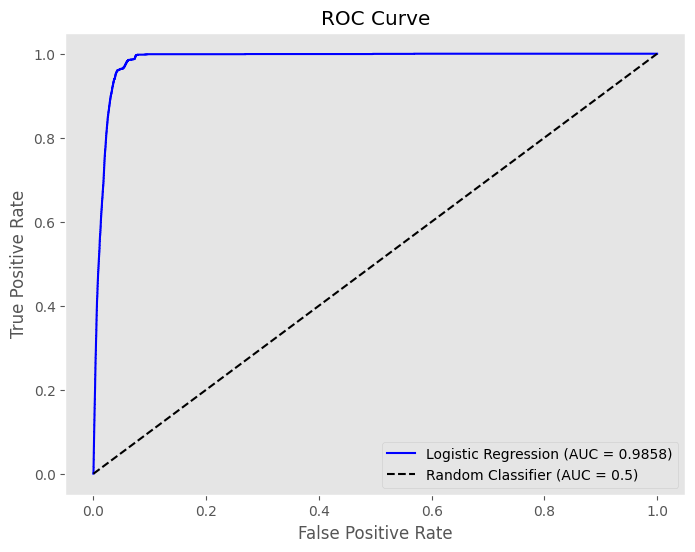

In [ ]:
# Get predicted probabilities for the positive class (class 1)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Compute AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC Score: {auc_score:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')  # Dashed diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

Very good AUC score - best looking classifier

In [ ]:
importance = pd.Series(log_reg.coef_[0], index=X_train.columns).sort_values(ascending=False)
print(importance)

Week_n_23                       19.783315
sea_water_practical_salinity    14.419529
Week_n_34                        9.455711
Week_n_32                        9.367743
Week_n_31                        6.763360
Week_n_36                        6.136402
Week_n_30                        4.412553
Week_n_37                       -0.000052
depth                           -0.575288
Week_n_46                       -1.594216
Week_n_26                       -1.722619
Week_n_25                       -2.704784
Week_n_28                       -3.047588
Week_n_48                       -3.175167
Week_n_47                       -3.527367
Week_n_29                       -3.549479
Week_n_24                       -3.728615
Week_n_35                       -3.954014
Week_n_27                       -4.368216
sea_water_temperature           -6.418631
Week_n_33                       -6.823811
sea_water_density              -19.528645
dtype: float64


# Random Forest

* In this section, we test Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split

df3=df2.copy()

# Define features and target
features = ['sea_water_temperature', 'sea_water_practical_salinity',
            'sea_water_density', 'depth', 'Season']
target = 'hypoxia'

# normalization of numerical vars
scaler = StandardScaler()
num_features = ['sea_water_temperature', 'sea_water_practical_salinity',
                'sea_water_density', 'depth']
df3[num_features] = scaler.fit_transform(df3[num_features])

# One-hot encoding categorical variables
categorical_features = ['Season']
df3 = pd.get_dummies(df3, columns=categorical_features, drop_first=True)

features = [col for col in df3.columns if col not in [
    'hypoxia', 'time', 'date_check',
    'micromoles_of_oxygen_per_unit_mass_in_sea_water',
    'Year_n','Day_n', 'Hour', 'quadrant', 'temp_salinity', 'temp_density',
    'temp_depth', 'salinity_density', 'salinity_depth', 'density_depth',
    'Month_n', 'Week_n','DayNight'
]]

X = df3[features]
X.columns

Index(['latitude', 'longitude', 'depth', 'sea_water_temperature',
       'sea_water_practical_salinity', 'sea_water_density', 'lat_idx',
       'lon_idx', 'Season_Summer', 'Season_Winter'],
      dtype='object')

In [ ]:
# Step 1: Prepare feature matrix and target
X = df3[features]
y = df3[target]

# Step 2: Split the data into training and testing sets (70/30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Step 3: Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=3, random_state=42, class_weight={0: 1, 1: 50})
rf_model.fit(X_train, y_train)

# Step 4: Set empirical threshold (e.g., 0.05) for feature selection
threshold = 0.05  # Features with importance greater than 0.05 will be selected

# Step 5: Feature selection using SelectFromModel with the empirical threshold
sfm = SelectFromModel(rf_model, threshold=threshold)
sfm.fit(X_train, y_train)

# Step 6: Get the important features
important_features = X_train.columns[sfm.get_support()]
print(f"Important Features (with importance > {threshold}): {important_features}")

# Step 7: Subset the training and testing sets to include only important features
X_train_important = X_train[important_features]
X_test_important = X_test[important_features]

# Step 8: Train the model using only the important features
rf_model.fit(X_train_important, y_train)

# Step 9: Predict and evaluate the model
from sklearn.metrics import accuracy_score, classification_report
y_pred = rf_model.predict(X_test_important)

# Model evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

Important Features (with importance > 0.05): Index(['latitude', 'longitude', 'depth', 'sea_water_temperature',
       'sea_water_practical_salinity', 'sea_water_density'],
      dtype='object')
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1355278
           1       1.00      0.29      0.44         7

    accuracy                           1.00   1355285
   macro avg       1.00      0.64      0.72   1355285
weighted avg       1.00      1.00      1.00   1355285



* Accuracy appears perfect but precision for hypoxia is high. Therefore, the model does not predict false positives.
Recall for hypoxia is low which it captures only 29% of hypoxia cases. In addition F1-score is only 0.44 which reflects poor sensitivity to the positive class.

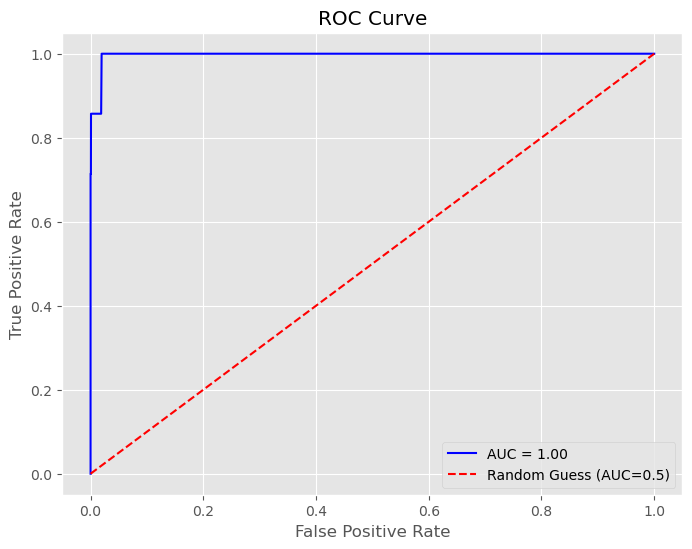

In [ ]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities for ROC curve
y_prob = rf_model.predict_proba(X_test_important)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


* AUC of 1 indicates that the model cannot predict class1 (hypoxia).

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold for Best F1 Score: {best_threshold:.2f}")

y_pred_adjusted = (y_prob >= best_threshold).astype(int)


Optimal Threshold for Best F1 Score: 0.14


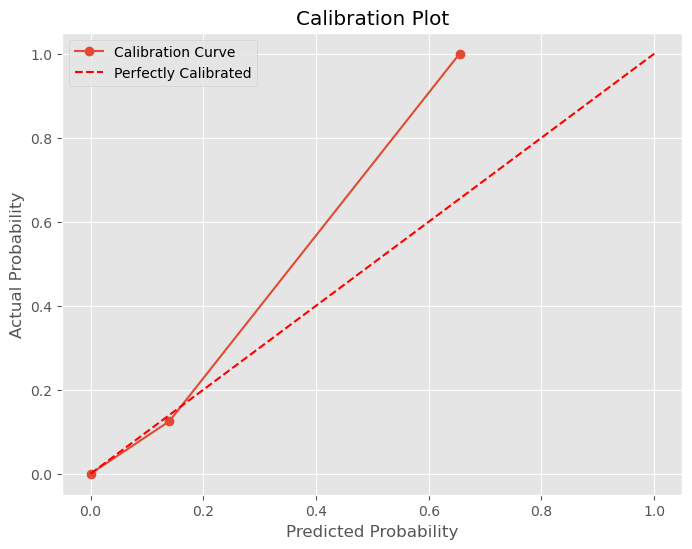

In [ ]:
from sklearn.calibration import calibration_curve

# Compute calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

# Plot Calibration Curve
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration Curve')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Perfectly Calibrated')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Probability')
plt.title('Calibration Plot')
plt.legend(loc="upper left")
plt.grid(True)
plt.show()


* Calibration line is slightly deviate from the perfect line. Therefore, it suggests that the predicted probabilities are not perfectly calibrated.

# XGBOOST -output got erased

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(scale_pos_weight=len(y_train_resampled) / sum(y_train_resampled == 1), random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Load and prepare data (assuming df2 is your original dataframe)
df3 = df2.copy()

# Define key oceanographic features
features = ['sea_water_temperature', 'sea_water_practical_salinity',
            'sea_water_density', 'depth', 'Hour', 'Month_n', 'Season', 'DayNight']
target = 'hypoxia'

# Normalization of numerical variables
scaler = StandardScaler()
num_features = ['sea_water_temperature', 'sea_water_practical_salinity',
                'sea_water_density', 'depth']
df3[num_features] = scaler.fit_transform(df3[num_features])

# One-hot encoding for categorical variables
categorical_features = ['Season', 'DayNight', 'Hour', 'Month_n']
df3 = pd.get_dummies(df3, columns=categorical_features, drop_first=True)

# Update features list after one-hot encoding


features = [col for col in df3.columns if col not in ['hypoxia', 'time', 'micromoles_of_oxygen_per_unit_mass_in_sea_water',
                                                    'temp_bins', 'salinity_bins', 'Depth Category','temp_salinity','temp_density','temp_depth','salinity_density','salinity_depth','density_depth','temp_salinity_bins','temp_depth_bins','salinity_density_bins','salinity_depth_bins','density_depth_bins','lat_binF','lon_binF', 'Year_n', 'Day_n','Hour','lat','lat_idx', 'lon_idx', 'quadrant']]
# Train-test split
X = df3[features]
y = df3[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Handle class imbalance using SMOTE (as in reference)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Calculate class weight ratio for XGBoost
scale_pos_weight = len(y_train_resampled[y_train_resampled == 0]) / len(y_train_resampled[y_train_resampled == 1])

# Initialize and train XGBoost model
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    max_depth=5,           # Reduced for oceanographic data
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # Probability estimates

# Evaluation metrics
print("XGBoost Performance:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

# Feature Importance Visualization
plt.figure(figsize=(12, 8))
sorted_idx = xgb_model.feature_importances_.argsort()
plt.barh(np.array(features)[sorted_idx], xgb_model.feature_importances_[sorted_idx])
plt.xlabel("XGBoost Feature Importance")
plt.title("Oceanographic Feature Importance for Hypoxia Prediction")
plt.tight_layout()
plt.show()

# Cross-validation (on resampled data)
X_resampled = pd.concat([X_train_resampled, pd.Series(y_train_resampled, name=target)], axis=1)
cv_scores = cross_val_score(
    xgb_model,
    X_train_resampled,
    y_train_resampled,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print(f"Cross-validation F1 scores: {cv_scores}")
print(f"Mean CV F1 score: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")

# Threshold optimization (optional)
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
optimal_idx = np.argmax(precisions * recalls)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal probability threshold: {optimal_threshold:.4f}")

In [ ]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores_xgb = cross_val_score(xgb_model, X_resampled, y_resampled, cv=5, scoring='f1')

# Print cross-validation scores and mean score
print(f"XGBoost Cross-validation F1 scores: {cv_scores_xgb}")
print(f"Mean XGBoost cross-validation F1 score: {cv_scores_xgb.mean()}")


In [ ]:
# For XGBoost models
importances = xgb_model.feature_importances_

# Visualize feature importances
plt.figure(figsize=(12, 6))
plt.barh(features, importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance for Predicting Hypoxia')
plt.show()


# Polynomial  -output got erased

In [ ]:
# Import necessary libraries for regression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

df3 = df2.copy()

# Define core features and target
core_features = ['sea_water_temperature', 'sea_water_practical_salinity',
                 'sea_water_density', 'depth']
target = 'hypoxia'

# Normalize numerical features
scaler = StandardScaler()
df3[core_features] = scaler.fit_transform(df3[core_features])

X = df3[core_features]
y = df3[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Polynomial Regression Pipeline with degree 2
degree = 2
poly_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree)),
    ('lin_reg', LinearRegression())
])

# Fit model
poly_model.fit(X_train, y_train)

# Predictions
y_pred = poly_model.predict(X_test)

# Evaluation
print("Polynomial Regression Results:")
print("R² score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

#  Visualize predicted vs actual values
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Hypoxia')
plt.ylabel('Predicted Hypoxia')
plt.title('Actual vs Predicted Hypoxia (Polynomial Regression)')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Define degree of polynomial (start with 2, then experiment)
degree = 2

core_features = ['sea_water_temperature', 'sea_water_practical_salinity', 'sea_water_density', 'depth']
X = df3[core_features]
y = df3['hypoxia']

# Create polynomial features
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

# Fit model
poly_model.fit(X, y)

# Get predictions
y_pred = poly_model.predict(X)

# Evaluate model
from sklearn.metrics import r2_score, mean_squared_error
print("R² score:", r2_score(y, y_pred))
print("MSE:", mean_squared_error(y, y_pred))


# t-tests  -output got erased

In [ ]:
# prev vars are:
X.columns

In [ ]:
df3 = df3[df3['Month_n'].isin([6, 7, 8])]

In [ ]:
from scipy.stats import ttest_ind

# Assuming 'hypoxia' is your oxygen level column
# Example: Comparing oxygen levels during day vs night
day_oxygen = df3[df3['DayNight_Day'] == 1]['hypoxia']  # Day oxygen levels
night_oxygen = df3[df3['DayNight_Night'] == 1]['hypoxia']  # Night oxygen levels

t_stat, p_value = ttest_ind(day_oxygen, night_oxygen)
print(f"T-statistic: {t_stat}, P-value: {p_value}")


In [ ]:
from scipy.stats import f_oneway

# Example: Comparing oxygen levels across different seasons
summer_oxygen = df3[df3['Season_Summer'] == 1]['hypoxia']
winter_oxygen = df3[df3['Season_Winter'] == 1]['hypoxia']
spring_oxygen = df3[df3['Season_Spring'] == 1]['hypoxia']
fall_oxygen = df3[df3['Season_Fall'] == 1]['hypoxia']

f_stat, p_value = f_oneway(summer_oxygen, winter_oxygen, spring_oxygen, fall_oxygen)
print(f"F-statistic: {f_stat}, P-value: {p_value}")


In [ ]:
from scipy.stats import chi2_contingency

# Example: Checking the relationship between 'DayNight' and hypoxia status
# Create a contingency table
contingency_table = pd.crosstab(df3['DayNight'], df3['hypoxia'])

# Perform Chi-Square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2-statistic: {chi2_stat}, P-value: {p_value}")


# Random Forest with Grid Search  -output got erased

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import numpy as np
import matplotlib.pyplot as plt

# Define the target and features for filtered data
features = ['sea_water_temperature', 'sea_water_practical_salinity', 'sea_water_density', 'Month_n']
target = 'micromoles_of_oxygen_per_unit_mass_in_sea_water'

# Drop NaN values
df2_filtered = df2_filtered.dropna(subset=features + [target])

# Sample a smaller portion of the dataset (for quicker training)
df2_filtered_sampled = df2_filtered.sample(n=500, random_state=42)  # Use 500 samples for faster training

# Define the features (X) and target (y)
X_filtered_sampled = df2_filtered_sampled[features]
y_filtered_sampled = df2_filtered_sampled[target]

# Apply log transformation on the target variable
y_filtered_sampled_log = np.log1p(y_filtered_sampled)  # Log(x + 1) to handle zero values

# Select only numerical features for the square root transformation
X_filtered_sampled_numerical = X_filtered_sampled.select_dtypes(include=[np.number])

# Apply square root transformation to the numerical features
X_filtered_sampled_sqrt = X_filtered_sampled_numerical.apply(np.sqrt)

# Handle categorical features separately, if any
X_filtered_sampled_categorical = X_filtered_sampled.select_dtypes(exclude=[np.number])

# Concatenate the transformed numerical features and the original categorical features
X_filtered_sampled_transformed = pd.concat([X_filtered_sampled_sqrt, X_filtered_sampled_categorical], axis=1)

# Perform a 70/30 train-test split
X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(
    X_filtered_sampled_transformed, y_filtered_sampled_log, test_size=0.3, random_state=42)

# Initialize RandomForestRegressor with n_estimators=20 and max_features='sqrt'
rf_regressor = RandomForestRegressor(n_estimators=20, max_features='sqrt', random_state=42)

# Train the model using the transformed data
rf_regressor.fit(X_train_filtered, y_train_filtered)

# Predict on both training and test sets
y_train_pred_rf = rf_regressor.predict(X_train_filtered)
y_test_pred_rf = rf_regressor.predict(X_test_filtered)

# Calculate MSE, RMSE, and R² for both training and test sets
mse_train_rf = mean_squared_error(y_train_filtered, y_train_pred_rf)
rmse_train_rf = np.sqrt(mse_train_rf)  # Root Mean Squared Error
r2_train_rf = r2_score(y_train_filtered, y_train_pred_rf)

mse_test_rf = mean_squared_error(y_test_filtered, y_test_pred_rf)
rmse_test_rf = np.sqrt(mse_test_rf)  # Root Mean Squared Error
r2_test_rf = r2_score(y_test_filtered, y_test_pred_rf)

# Print results
print("Random Forest Results:")
print(f"Training MSE: {mse_train_rf:.4f}, Training RMSE: {rmse_train_rf:.4f}, Training R²: {r2_train_rf:.4f}")
print(f"Test MSE: {mse_test_rf:.4f}, Test RMSE: {rmse_test_rf:.4f}, Test R²: {r2_test_rf:.4f}")

# Feature Importance
importances = rf_regressor.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort in descending order

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Random Forest)")
plt.barh(range(len(features)), importances[indices], align="center")
plt.yticks(range(len(features)), np.array(features)[indices])
plt.xlabel("Feature Importance")
plt.show()

# Plot residuals for the random forest model
residuals_train_rf = y_train_filtered - y_train_pred_rf
residuals_test_rf = y_test_filtered - y_test_pred_rf

# Plot residuals
plt.figure(figsize=(10, 6))

# Plot residuals for training data
plt.subplot(1, 2, 1)
plt.scatter(y_train_pred_rf, residuals_train_rf, color='blue', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Oxygen Concentration (Training) [Log Transformed]")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Training Data - Random Forest)")

# Plot residuals for test data
plt.subplot(1, 2, 2)
plt.scatter(y_test_pred_rf, residuals_test_rf, color='green', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Oxygen Concentration (Test) [Log Transformed]")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Test Data - Random Forest)")

# Show the plot
plt.tight_layout()
plt.show()

# Residuals Histogram
plt.figure(figsize=(10, 6))
plt.hist(residuals_test_rf, bins=30, color='green', alpha=0.6, label='Test Residuals')
plt.axvline(0, color='red', linestyle='--', label='Zero Residuals')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Histogram (Test Data - Random Forest)")
plt.legend()
plt.show()

# Hyperparameter Tuning with GridSearchCV (Optional, if you'd like to tune the model)
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [None, 10, 20, 30],  # Depth of trees
    'min_samples_split': [2, 5, 10],  # Min samples to split a node
    'min_samples_leaf': [1, 2, 4],    # Min samples at a leaf node
    'max_features': ['auto', 'sqrt', 'log2']  # Number of features to consider
}

# Grid Search
grid_search = GridSearchCV(estimator=rf_regressor, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_filtered, y_train_filtered)

# Print best parameters
print("Best Parameters from GridSearchCV:", grid_search.best_params_)
